# Envelope Strategy — Backtest
Multi-band mean-reversion envelope strategy around a moving average. Scales into a position as price pierces each successively lower (or higher) band and exits on the central MA.

All code uses the Polars-native `quant_research` library.

In [1]:
import polars as pl
from quant_research.connectors import CCXTLoader
from quant_research.strategies import EnvelopeStrategy
from quant_research.backtest import BacktestAnalysis

In [2]:
loader = CCXTLoader(exchange="binanceusdm")

In [3]:
symbol = "BTC/USDT:USDT"
ohlcv = loader.load(symbol, timeframe="1h", start_date="2021-01-01 00:00:00")

strategy_params = {
    "average_type": "SMA",       # 'SMA', 'EMA', 'WMA', 'DCM'
    "average_period": 6,
    "envelopes": [0.07, 0.11, 0.14],
    "stop_loss_pct": 0.3,
    # "price_jump_pct": 0.3,
    "position_size_percentage": 100,
    # "mode": "long" | "short" | "both"  (default 'both')
}

strategy = EnvelopeStrategy(strategy_params, ohlcv)
strategy.run_backtest(initial_balance=1000, leverage=1, open_fee_rate=0.0002, close_fee_rate=0.0006)

open_time,close_time,open_reason,close_reason,open_price,close_price,initial_margin,net_pnl,net_pnl_pct,open_notional_value,close_notional_value,amount,open_fee,close_fee,sl_price,tp_price,liquidation_price,open_balance,close_balance
datetime[μs],datetime[μs],str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,null,f64,f64,f64
2024-04-13 20:00:00,2024-04-13 23:00:00,"""Open long 1""","""Exit long""",62221.6345,64625.9,333.3,12.601926,3.780956,333.23334,346.109592,0.005356,0.06666,0.207666,43555.14415,null,0.0,666.7,1012.601926
2024-08-05 01:00:00,2024-08-05 08:00:00,"""Open long 1""","""Exit long""",54217.0315,53157.1,337.500222,-6.86274,-2.033403,337.432722,330.835983,0.006224,0.0675,0.198502,37951.92205,null,0.0,675.101704,1005.739186
2024-12-05 22:00:00,2024-12-06 01:00:00,"""Open long 1""","""Exit long""",92988.189,98072.95,335.212871,18.047249,5.383818,335.145828,353.472203,0.003604,0.067043,0.212083,65091.7323,null,0.0,670.526315,1023.786435
2025-01-20 06:00:00,2025-01-20 12:00:00,"""Open short 1""","""Exit short""",109095.519713,107914.033333,341.228019,3.419545,1.002129,341.159773,344.854477,0.003127,0.068246,0.206913,141824.175627,null,218191.039427,682.558416,1027.205981
2025-03-02 17:00:00,2025-03-02 23:00:00,"""Open short 1""","""Exit short""",93422.831541,93826.316667,342.367753,-1.751327,-0.511534,342.29928,340.820919,0.003664,0.068474,0.204493,121449.681004,null,186845.663082,684.838227,1025.454654
2025-10-10 21:00:00,2025-10-11 02:00:00,"""Open long 2""","""Exit long""",106993.095419,112882.683333,569.651453,30.876544,5.420252,569.537523,600.88853,0.005323,0.11393,0.360533,74895.166793,null,0.0,455.803201,1056.331197
2026-01-31 18:00:00,2026-01-31 23:00:00,"""Open long 1""","""Exit long""",75541.9935,78147.566667,352.075188,11.852347,3.366425,352.004773,364.146023,0.00466,0.070415,0.218488,52879.39545,null,0.0,704.256009,1068.183544
2026-02-05 20:00:00,2026-02-05 23:00:00,"""Open long 1""","""Exit long""",62431.4425,64753.633333,356.025575,12.947305,3.636622,355.95437,369.194397,0.005702,0.071205,0.221517,43702.00975,null,0.0,712.157969,1081.130849


In [4]:
results = BacktestAnalysis(strategy)
results.print_metrics()

--- General ---
Period: [2024-04-01 03:00:00] -> [2026-04-22 09:00:00]
Initial balance: 1000.0 $
Final balance:   1081.13 $
Performance:     8.11 %
Hodl perf:       10.35 %
Perf vs Hodl:    -2.02 %
Total trades:    8
Time in pos:     0.21 %

--- Health ---
Win rate:        75.0 %
Max DD trades:   -0.68 %
Max DD equity:   -0.68 %
Profit factor:   10.42
ROI / MaxDD:     11.97
Sharpe:          0.66
Sortino:         0.34
Calmar:          1.41

--- Trades ---
Avg net PnL:     2.51 %
Avg trades/day:  0.011
Avg duration:    4:45:00
Best trade:      +5.42 % 2025-10-10 21:00:00 -> 2025-10-11 02:00:00
Worst trade:     -2.03 % 2024-08-05 01:00:00 -> 2024-08-05 08:00:00
Winners:         6
Losers:          2
Avg win pnl %:   3.77
Avg lose pnl %:  -1.27
Max win streak:  3
Max lose streak: 1

Open reasons:
  Open long 1: 5
  Open short 1: 2
  Open long 2: 1
Close reasons:
  Exit long: 6
  Exit short: 2

--- Fees (quote) ---
Total:    2.42
Biggest:  0.47
Average:  0.3



In [5]:
strategy.trades_info

open_time,close_time,open_reason,close_reason,open_price,close_price,initial_margin,net_pnl,net_pnl_pct,open_notional_value,close_notional_value,amount,open_fee,close_fee,sl_price,tp_price,liquidation_price,open_balance,close_balance
datetime[μs],datetime[μs],str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,null,f64,f64,f64
2024-04-13 20:00:00,2024-04-13 23:00:00,"""Open long 1""","""Exit long""",62221.6345,64625.9,333.3,12.601926,3.780956,333.23334,346.109592,0.005356,0.06666,0.207666,43555.14415,null,0.0,666.7,1012.601926
2024-08-05 01:00:00,2024-08-05 08:00:00,"""Open long 1""","""Exit long""",54217.0315,53157.1,337.500222,-6.86274,-2.033403,337.432722,330.835983,0.006224,0.0675,0.198502,37951.92205,null,0.0,675.101704,1005.739186
2024-12-05 22:00:00,2024-12-06 01:00:00,"""Open long 1""","""Exit long""",92988.189,98072.95,335.212871,18.047249,5.383818,335.145828,353.472203,0.003604,0.067043,0.212083,65091.7323,null,0.0,670.526315,1023.786435
2025-01-20 06:00:00,2025-01-20 12:00:00,"""Open short 1""","""Exit short""",109095.519713,107914.033333,341.228019,3.419545,1.002129,341.159773,344.854477,0.003127,0.068246,0.206913,141824.175627,null,218191.039427,682.558416,1027.205981
2025-03-02 17:00:00,2025-03-02 23:00:00,"""Open short 1""","""Exit short""",93422.831541,93826.316667,342.367753,-1.751327,-0.511534,342.29928,340.820919,0.003664,0.068474,0.204493,121449.681004,null,186845.663082,684.838227,1025.454654
2025-10-10 21:00:00,2025-10-11 02:00:00,"""Open long 2""","""Exit long""",106993.095419,112882.683333,569.651453,30.876544,5.420252,569.537523,600.88853,0.005323,0.11393,0.360533,74895.166793,null,0.0,455.803201,1056.331197
2026-01-31 18:00:00,2026-01-31 23:00:00,"""Open long 1""","""Exit long""",75541.9935,78147.566667,352.075188,11.852347,3.366425,352.004773,364.146023,0.00466,0.070415,0.218488,52879.39545,null,0.0,704.256009,1068.183544
2026-02-05 20:00:00,2026-02-05 23:00:00,"""Open long 1""","""Exit long""",62431.4425,64753.633333,356.025575,12.947305,3.636622,355.95437,369.194397,0.005702,0.071205,0.221517,43702.00975,null,0.0,712.157969,1081.130849


In [6]:
strategy.equity_record

time,price,equity
datetime[μs],f64,f64
2024-04-01 03:00:00,70650.1,1000.0
2024-04-01 09:00:00,69448.4,1000.0
2024-04-01 15:00:00,68281.0,1000.0
2024-04-01 21:00:00,69629.1,1000.0
2024-04-02 03:00:00,66734.1,1000.0
…,…,…
2026-04-21 09:00:00,76324.2,1081.130849
2026-04-21 15:00:00,75799.9,1081.130849
2026-04-21 21:00:00,75506.4,1081.130849


In [7]:
results.plot_equity()

alt.LayerChart(...)

In [8]:
results.plot_drawdown()

alt.LayerChart(...)

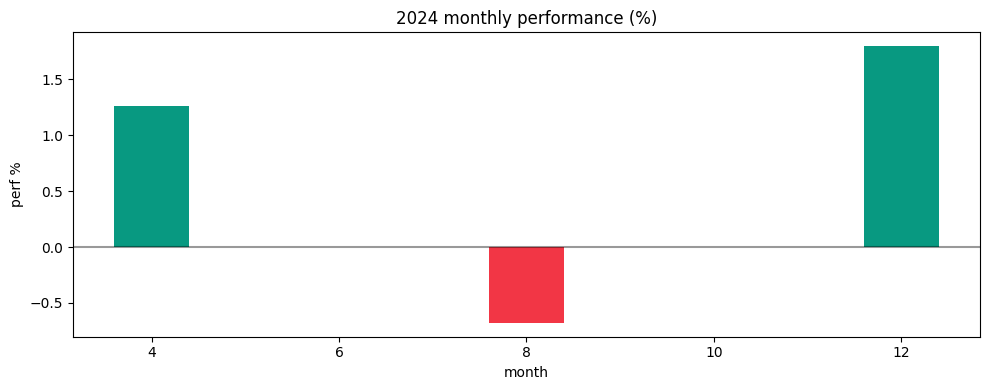

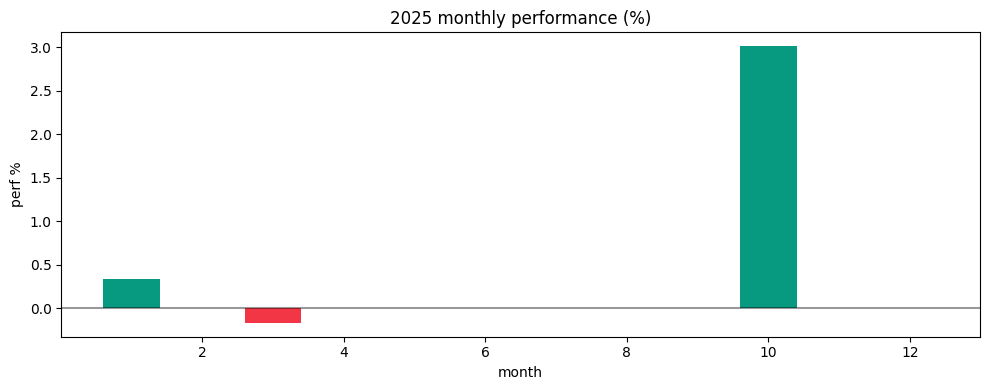

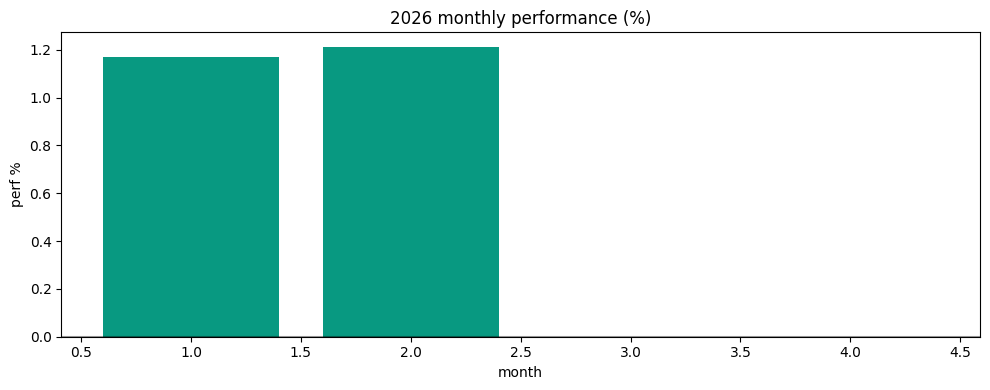

[<Figure size 1000x400 with 1 Axes>,
 <Figure size 1000x400 with 1 Axes>,
 <Figure size 1000x400 with 1 Axes>]

In [9]:
results.plot_monthly_performance(year="all")

In [10]:
indicators = {
    "average": {
        "color": "white",
        "df": strategy.data.select(pl.col("datetime").alias("time"), pl.col("average")).drop_nulls(),
    }
}
for i, _ in enumerate(strategy_params["envelopes"], start=1):
    for side, color in (("high", "red"), ("low", "green")):
        col = f"band_{side}_{i}"
        indicators[col] = {
            "color": color,
            "df": strategy.data.select(pl.col("datetime").alias("time"), pl.col(col)).drop_nulls(),
        }

results.plot_candlestick(indicators=indicators)

MaxRowsError: The number of rows in your dataset (18036) is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.LayerChart(...)